In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

from pyDeepInsight import ImageTransformer

Generate example classification dataset

In [ ]:
X, y = make_classification(n_samples=500, n_features=150, n_informative=15,
                           n_redundant=15, n_classes=3, random_state=42)
# MinMaxScale
X = (X - X.min())/(X.max() - X.min())

Create image transformers for 'bin' and 'lsa' discridiscretization.

In [ ]:
!python3 -m pip -q install git+https://github.com/alok-ai-lab/pyDeepInsight.git#egg=pyDeepInsight

  Preparing metadata (setup.py) ... done


In [ ]:
pixel_size = (12,12)

In [ ]:
# Create and train image transformer
tsne = TSNE(n_components=2, n_jobs=-1)
it_tsne_bin = ImageTransformer(feature_extractor=tsne,
                           pixels=pixel_size, discretization='bin')
# generate single channel image
X_bin_img = it_tsne_bin.fit_transform(X, img_format='scalar')

In [ ]:
# Create a deep copy to preserve the original manifold mapping
it_tsne_lsa = deepcopy(it_tsne_bin)
# update the internals and rerun coordinate calculation
it_tsne_lsa._dm = it_tsne_lsa._parse_discretization("lsa")
it_tsne_lsa._calculate_coords()
# generate single channel image
X_lsa_img = it_tsne_lsa.transform(X, img_format='scalar')

Generate plot using a combination of `subfigures()` and `subplots()`

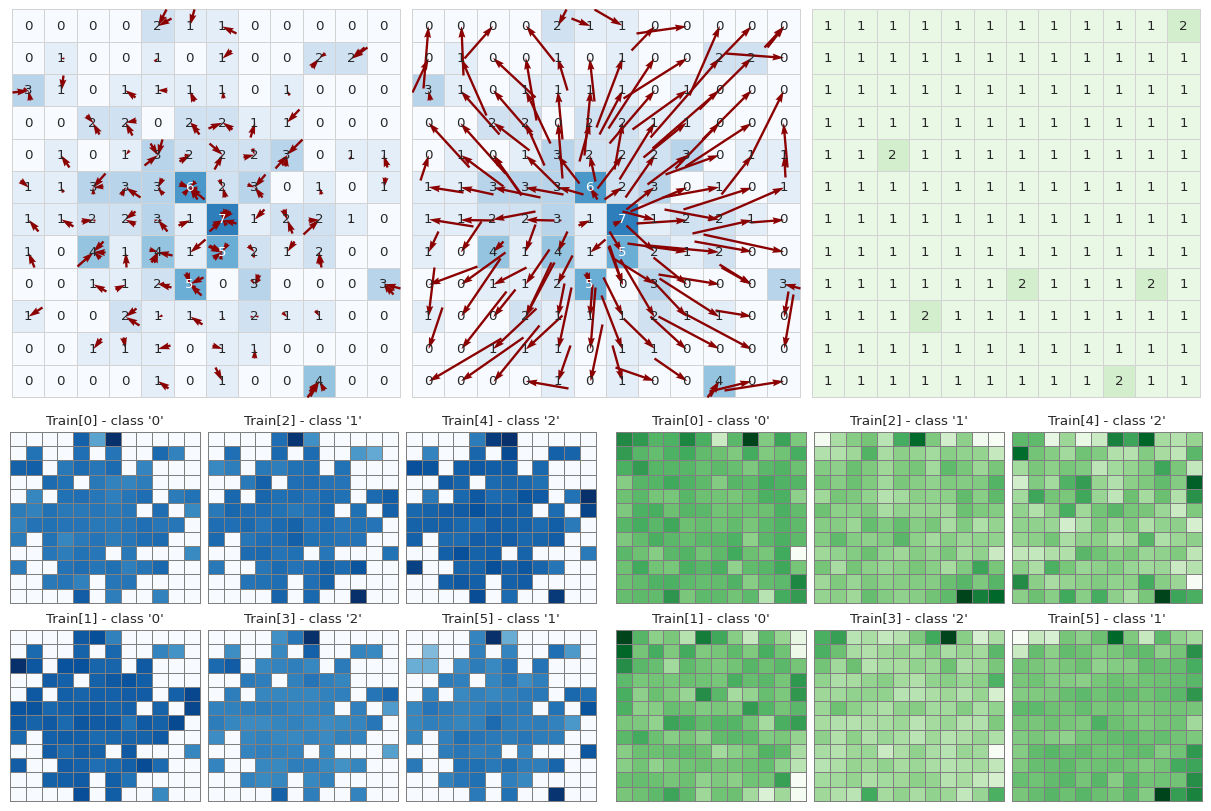

In [ ]:
fig = plt.figure(layout='constrained', figsize=(12, 8))
# Top level - two rows
subfigs = fig.subfigures(2, 1, wspace=0.07)

# top row - three columns
ax = subfigs[0].subplots(1,3)
sns.set(font_scale=.8)
# Top Left - 'bin' density with 'bin' mapping
# 'bin' density heatmap
_ = sns.heatmap(it_tsne_bin.feature_density_matrix(), linewidths=0.5,
                linecolor='lightgray', cbar=False,
                xticklabels=False, yticklabels=False,
                annot=True,
                cmap="Blues", square=True, clip_on=False,
                vmin=0, vmax=10, ax=ax[0])
# 'bin' mapping arrows
oc = it_tsne_bin._coords
os = it_tsne_bin.scale_coordinates(it_tsne_bin._xrot, it_tsne_bin._pixels)
for i in range(oc.shape[0]):
    px, py, dx, dy = os[i,1], os[i,0], (oc[i,1]+0.5)-os[i,1], (oc[i,0]+0.5)-os[i,0]
    ax[0].quiver(px, py, dx, dy, width=.006, scale_units='xy',
                 angles='xy', scale=1, color="darkred")

# Top Middle - 'bin' density with 'lsa' mapping
# 'bin' density heatmap
_ = sns.heatmap(it_tsne_bin.feature_density_matrix(), linewidths=0.5,
                linecolor='lightgray', cbar=False,
                xticklabels=False, yticklabels=False,
                annot=True,
                cmap="Blues", square=True, clip_on=False,
                vmin=0, vmax=10, ax=ax[1])
# 'lsa' mapping arrows
oc = it_tsne_lsa._coords
os = it_tsne_lsa.scale_coordinates(it_tsne_lsa._xrot, it_tsne_lsa._pixels)
for i in range(oc.shape[0]):
    px, py, dx, dy = os[i,1], os[i,0], (oc[i,1]+0.5)-os[i,1], (oc[i,0]+0.5)-os[i,0]
    ax[1].quiver(px, py, dx, dy, width=.006, scale_units='xy',
                 angles='xy', scale=1, color="darkred")
# Top Left - 'lsa' density
# 'bin' density heatmap
_ = sns.heatmap(it_tsne_lsa.feature_density_matrix(), linewidths=0.5,
                linecolor='lightgray', cbar=False,
                xticklabels=False, yticklabels=False,
                annot=True,
                cmap="Greens", square=True, clip_on=False,
                vmin=0, vmax=10, ax=ax[2])

# bottom row - two columns
subsubfigs = subfigs[1].subfigures(1,2)
# bottom row, left column - six subplots (2 rows, three columns)
ax = subsubfigs[0].subplots(2,3)
for i in range(0,6):
    r = i % 2
    c = i // 2
    sns.heatmap(X_bin_img[i], ax=ax[r][c], linewidths=0.5, linecolor='gray',
                xticklabels=False, yticklabels=False,
                cmap="Blues", cbar=False, clip_on=False)
    ax[r][c].title.set_text(f"Train[{i}] - class '{y[i]}'")
# bottom row, right column - six subplots (2 rows, three columns)
ax = subsubfigs[1].subplots(2,3)
for i in range(0,6):
    r = i % 2
    c = i // 2
    sns.heatmap(X_lsa_img[i], ax=ax[r][c], linewidths=0.5, linecolor='gray',
                xticklabels=False, yticklabels=False,
                cmap="Greens", cbar=False, clip_on=False)
    ax[r][c].title.set_text(f"Train[{i}] - class '{y[i]}'")